In [25]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import rasterio
from classification_aux import inpsectiontocsv
import os
import multiprocessing as mp

# modelling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [2]:
runname = ""
test_sites = ['CG1-8B', 'F3-20B', 'CS-96B', 'ZF20-11A']
chicken_columns = [f'chicken_{i}' for i in range(384)]

In [3]:
runpath = os.path.join('runs', runname)
if not os.path.exists(runpath):
    os.mkdir(runpath)

In [4]:
def split_by_sites(df, sites, remove_site=True):
    site_indices = df['site'].isin(sites)

    selection = list(df.columns)
    if remove_site:
        selection.remove('site')
    selection.remove('veg_class')

    X = df[selection]
    y = df['veg_class']
    X_train = X[~site_indices].reset_index(drop=True)
    X_test = X[site_indices].reset_index(drop=True)
    y_train = y[~site_indices].reset_index(drop=True)
    y_test = y[site_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [5]:
def split_by_columns(df, columns):
    df2 = df[columns]
    df1 = df.drop(columns, axis=1)
    return df1, df2

In [32]:
def run_experiment(X_train, X_test, y_train, y_test, extra_metrics=False):
    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=500, max_depth=10, n_jobs=6)
    clf.fit(X_res, y_res)

    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test)

    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
        disp.plot()
        plt.title('Confusion Matrix')

        feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

In [7]:
dfo = pd.read_csv("prior_dataset_transformed.csv") # Maria's original dataset
df = pd.read_csv("dataset_chm_shp_transformed.csv")
print(df)

              R         G         B  chm  veg_class      site  chicken_0   
0      0.109804  0.239216  0.129412    1          5   CS-103A  -0.263335  \
1      0.082353  0.211765  0.105882    1          5   CS-103A  -0.263335   
2      0.098039  0.223529  0.113725    1          5   CS-103A  -0.263335   
3      0.082353  0.211765  0.101961    1          5   CS-103A  -0.263335   
4      0.388235  0.505882  0.364706    3          6   CS-103A   0.121613   
...         ...       ...       ...  ...        ...       ...        ...   
22214  0.803922  0.760784  0.737255    1         13  ZF20-11A   0.330451   
22215  0.815686  0.780392  0.756863    1         13  ZF20-11A   0.330451   
22216  0.800000  0.760784  0.737255    1         13  ZF20-11A   0.330451   
22217  0.709804  0.666667  0.698039    2          7  ZF20-11A   0.461744   
22218  0.643137  0.600000  0.631373    2          7  ZF20-11A   0.461744   

       chicken_1  chicken_2  chicken_3  ...       ExR       ExB   ExGmExR   
0      -0.

In [27]:
mp.cpu_count()

40

In [19]:
dfcat = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]
print(dfcat.iloc[3000:3050])
print(dfo)

         site     veg_class         R         G         B  chm
8685  CS-103B     low_green  0.596078  0.678431  0.478431    1
1852  CS-103B            12  0.596078  0.678431  0.478431    2
8080  CS-103B    needleleaf  0.600000  0.658824  0.541176    1
1451  CS-103B             6  0.600000  0.658824  0.541176    2
8388  CS-103B    needleleaf  0.600000  0.666667  0.549020    2
2212  CS-103B             6  0.600000  0.666667  0.549020    1
7896  CS-103B     broadleaf  0.600000  0.721569  0.384314    2
2254  CS-103B             5  0.600000  0.721569  0.384314    1
7734  CS-103B     broadleaf  0.600000  0.768627  0.556863    2
1237  CS-103B             5  0.600000  0.768627  0.556863    3
8750  CS-103B     low_green  0.603922  0.639216  0.407843    2
2161  CS-103B            12  0.603922  0.639216  0.407843    1
8010  CS-103B    needleleaf  0.603922  0.654902  0.431373    3
1316  CS-103B             6  0.603922  0.654902  0.431373    2
8498  CS-103B          moss  0.607843  0.431373  0.2823

In [62]:
# Correct wrong chm values in new dataset, using old dataset as a reference.
# This is a temporary measure while I figure out a more efficient way to get accurate chm values
# from the low resolution raster
df_reduced = df[df['site'].isin(dfo['site'].unique())]
dfm = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]
print(dfm)
print('cleaning chm values')
#dfm.to_csv('test1.csv')
for i, (index, cur_row) in enumerate(dfm.iterrows()):
    if i == 0:
        continue
    prv_row = dfm.iloc[i-1]
    if prev_row['site'] == curr_row['site'] and \
       prev_row['R'] == curr_row['R'] and \
       prev_row['G'] == curr_row['G'] and \
       prev_row['B'] == curr_row['B'] and \
       type(prev_row['veg_class']) == str: # this ensures we're copying from Maria's data to ours
        df.loc[index, 'chm'] = prv_row['chm']

df_reduced = df[df['site'].isin(dfo['site'].unique())]
dfm = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]

#dfm.to_csv('test2.csv')
print(dfm)

           site  veg_class         R         G         B  chm
868      CG1-8A          7  0.352941  0.427451  0.490196    3
618      CG1-8A       moss  0.462745  0.494118  0.337255    1
714      CG1-8A          9  0.462745  0.494118  0.337255    2
968      CG1-8A  low_green  0.466667  0.588235  0.376471    1
780      CG1-8A         12  0.466667  0.588235  0.376471    3
...         ...        ...       ...       ...       ...  ...
20978     F3-8B          1  0.988235  0.988235  0.964706    3
12341     F3-8C  broadleaf  0.086275  0.164706  0.129412    3
22868     F3-8C         10  0.286275  0.290196  0.278431    3
20156  ZF20-11A  low_green  0.725490  0.823529  0.611765    2
21419  ZF46-15A       soil  0.400000  0.380392  0.360784    2

[78 rows x 6 columns]
cleaning chm values
           site  veg_class         R         G         B  chm
643      CG1-8A       soil  0.321569  0.266667  0.227451    1
326      CG1-8A         10  0.321569  0.266667  0.227451   -1
868      CG1-8A          7 

In [10]:
# some data subsets to play with
dfr = df[df['site'].isin(dfo['site'].unique())]
dfn, _ = split_by_columns(df, chicken_columns)
dfrn, _ = split_by_columns(dfr, chicken_columns)

In [20]:
# Maria's original dataset
X_train, X_test, y_train, y_test = split_by_sites(dfo, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.997542690545606
  Test accuracy: 0.6789957408652768


In [21]:
# New dataset with default columns (almost every row is identical to Maria's original dataset)
X_train, X_test, y_train, y_test = split_by_sites(dfrn, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 1.0
  Test accuracy: 0.6770149253731343


In [22]:
# New dataset with texture data (original sites only)
X_train, X_test, y_train, y_test = split_by_sites(dfr, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 1.0
  Test accuracy: 0.6650746268656716


In [23]:
# New dataset with *all* sites (no texture data)
X_train, X_test, y_train, y_test = split_by_sites(dfn, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 1.0
  Test accuracy: 0.6576119402985074


In [31]:
# New dataset with *all* texture features and new sites
X_train, X_test, y_train, y_test = split_by_sites(df, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 1.0
  Test accuracy: 0.6444776119402985


<Axes: >

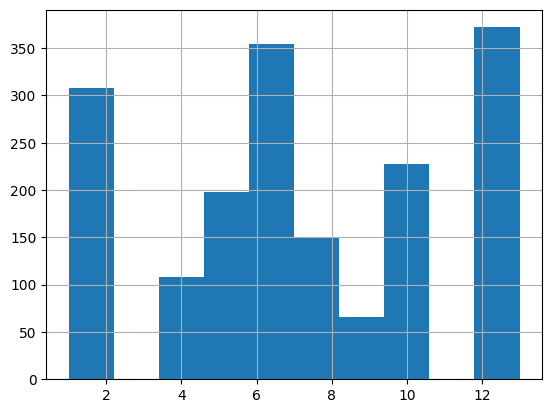

In [45]:
df1 = dfn[dfn['site'] == 'CS3A']
df1['veg_class'].hist()

<Axes: >

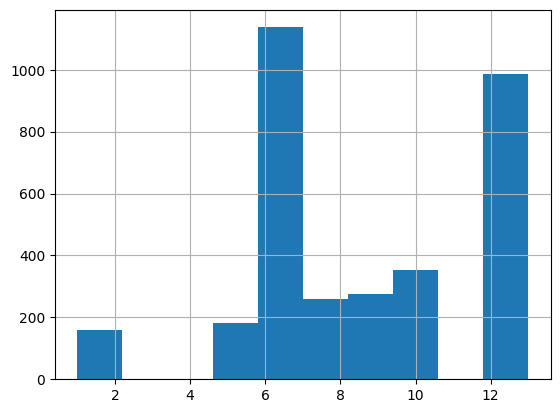

In [38]:
y_test.hist()

In [69]:
# New dataset with *some* features
num_features = 16
df_base, df_chicken = split_by_columns(df, chicken_columns)
df_chicken = df_chicken.iloc[:, :num_features]
df_16 = pd.concat([df_base, df_chicken], axis=1)

X_train, X_test, y_train, y_test = split_by_sites(df_16, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.9995060102091223
  Test accuracy: 0.688859000224165


In [70]:
# New dataset with more features
num_features = 32
df_base, df_chicken = split_by_columns(df, chicken_columns)
df_chicken = df_chicken.iloc[:, :num_features]
df_32 = pd.concat([df_base, df_chicken], axis=1)

X_train, X_test, y_train, y_test = split_by_sites(df_32, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.9996706734727482
  Test accuracy: 0.6884106702533064


In [71]:
# New dataset with embedding of texture features
num_features = 32

# We're going to split the train data into train/val, so we can train an encoder on texture features
X_train, X_test, y_train, y_test = split_by_sites(df, test_sites)

# Peel off the texture features in the train set so we can train an encoder
df_main_tr, df_chicken_tr = split_by_columns(X_train, chicken_columns)
df_main_te, df_chicken_te = split_by_columns(X_test, chicken_columns)

softmax_to_class = {1:0, 4:1, 5:2, 6:3, 7:4, 8:5, 9:6, 10:7, 12:8, 13:9}

xt = torch.tensor(df_chicken_tr.values, dtype=torch.float)
yt = torch.tensor([softmax_to_class[y] for y in y_train.values])

In [72]:
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sm =  nn.Softmax(dim=0)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.constant_(self.fc1.bias, 0)  # Initialize bias to zero
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)  # Initialize bias to zero

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def encode(self, x):
        return self.fc1(x)

In [73]:
network = FFNN(384, num_features, 10)
loss_fn = nn.CrossEntropyLoss()
opt = optim.AdamW(network.parameters())

dataset = TensorDataset(xt, yt)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Specify the number of epochs
num_epochs = 1001

# Iterate over the dataloader for multiple epochs
for epoch in range(num_epochs):
    for inputs, targets in dataloader:

        y_pred = network(inputs)
        
        loss = loss_fn(y_pred, targets)
        opt.zero_grad()
        loss.backward()
        opt.step()
    if epoch%100 == 0:
        print(f'Finished epoch {epoch}, latest loss {loss}')

Finished epoch 0, latest loss 1.8197065591812134
Finished epoch 100, latest loss 0.41513949632644653
Finished epoch 200, latest loss 0.15488745272159576
Finished epoch 300, latest loss 0.15742184221744537
Finished epoch 400, latest loss 0.24555604159832
Finished epoch 500, latest loss 0.0685320794582367
Finished epoch 600, latest loss 0.19337759912014008
Finished epoch 700, latest loss 0.049202874302864075
Finished epoch 800, latest loss 0.026132646948099136
Finished epoch 900, latest loss 0.04345347359776497
Finished epoch 1000, latest loss 0.04708768054842949


In [74]:
df_chicken_tr_reduced = pd.DataFrame(network.encode(torch.tensor(df_chicken_tr.values, dtype=torch.float)).detach().numpy(), columns=[f'chicken_{i}' for i in range(num_features)])
df_chicken_te_reduced = pd.DataFrame(network.encode(torch.tensor(df_chicken_te.values, dtype=torch.float)).detach().numpy(), columns=[f'chicken_{i}' for i in range(num_features)])

# Concat the reduced texture features back onto the rgb features
X_train = pd.concat([df_main_tr, df_chicken_tr_reduced], axis=1)
X_test = pd.concat([df_main_te, df_chicken_te_reduced], axis=1)

run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.9998188704100115
  Test accuracy: 0.6895314951804528


[  0 275 274 273 272 271 270 269 268 267 266 265 264 263 262 261 260 259
 258 257 256 255 276 254 277 279 300 299 298 297 296 295 294 293 292 291
 290 289 288 287 286 285 284 283 282 281 280 278 253 252 251 224 223 222
 221 220 219 218 217 216 215 214 213 212 211 210 209 208 207 206 205 204
 225 226 227 228 250 249 248 247 246 245 244 243 242 241 301 240 238 237
 236 235 234 233 232 231 230 229 239 203 302 304 376 375 374 373 372 371
 370 369 368 367 366 365 364 363 362 361 360 359 358 357 356 377 355 378
 380 401 400 399 398 397 396 395 394 393 392 391 390 389 388 387 386 385
 384 383 382 381 379 354 353 352 325 324 323 322 321 320 319 318 317 316
 315 314 313 312 311 310 309 308 307 306 305 326 327 328 329 351 350 349
 348 347 346 345 344 343 342 303 341 339 338 337 336 335 334 333 332 331
 330 340 202 201 200  72  71  70  69  68  67  66  65  64  63  62  61  60
  59  58  57  56  55  54  53  52  73  51  74  76  97  96  95  94  93  92
  91  90  89  88  87  86  85  84  83  82  81  80  7

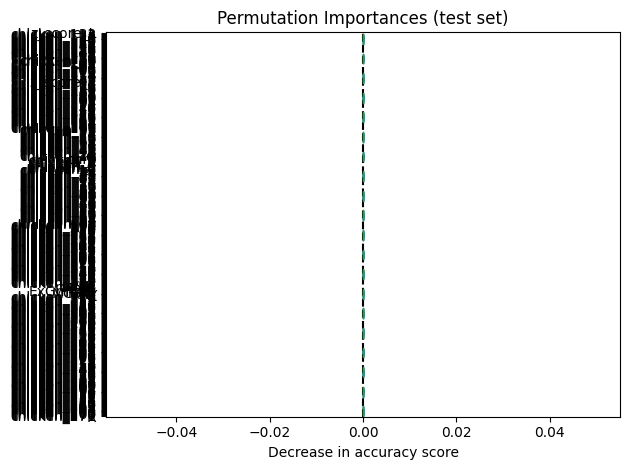

In [21]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [6]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 

['data/clfs/clf_run6_orthotest_500-15_TEST.pkl']